# 03. Embeddings

**Tier:** Foundations
**Estimated time:** 40 minutes
**Prerequisites:** 00, 01, 02
**Source material:** @sairahul1 — "20 AI Concepts You Must Understand in 2026"

## What You'll Learn
- What an **embedding** is: a vector that places meaning in space, where *nearby = similar*
- How **cosine similarity** measures relatedness, and why we use angle instead of distance
- How to visualize a "meaning map" and build a tiny **semantic search** — the engine behind RAG (notebook 14)

## Why This Matters
Token IDs are arbitrary integers — ID 5 isn't "closer" to ID 6 than to ID 5000. Embeddings fix that by mapping tokens (and whole sentences) into a space where geometric closeness means semantic closeness. This single idea powers search, RAG, recommendation, clustering, and the input layer of every LLM.

## The core analogy: a map of meaning

Imagine a giant map where every word and sentence is a pin. Pins for *dog*, *cat*, *hamster* cluster in one neighbourhood; *Tokyo*, *Paris*, *Cairo* cluster in another. The map has hundreds of dimensions (MiniLM uses 384), not two — but the principle is the same: **direction and proximity encode meaning.**

An embedding model is trained so that texts with similar meaning get similar vectors. We measure "similar" with **cosine similarity** — the cosine of the angle between two vectors:

- **1.0** → same direction (very similar)
- **0.0** → perpendicular (unrelated)
- **−1.0** → opposite

We use the *angle* rather than raw distance so that long and short texts compare fairly — only direction matters, not magnitude.

In [1]:
import numpy as np
from sentence_transformers import SentenceTransformer

# all-MiniLM-L6-v2: small, fast, 384-dim. Cached locally so this is offline-friendly.
model = SentenceTransformer("all-MiniLM-L6-v2")

vec = model.encode("a friendly dog")
print("Embedding shape:", vec.shape)      # (384,)
print("First 8 numbers:", np.round(vec[:8], 3))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding shape: (384,)
First 8 numbers: [-0.015 -0.022  0.002  0.065 -0.019 -0.003  0.064 -0.047]


In [2]:
def cosine_similarity(a, b):
    """Cosine of the angle between two vectors: dot product over the product of norms."""
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

dog   = model.encode("a friendly dog")
puppy = model.encode("a young puppy")
car   = model.encode("a red sports car")

print(f"dog vs puppy : {cosine_similarity(dog, puppy):.3f}   (related)")
print(f"dog vs car   : {cosine_similarity(dog, car):.3f}   (unrelated)")

dog vs puppy : 0.503   (related)
dog vs car   : 0.130   (unrelated)


## A similarity heatmap

Let's embed a mixed bag of words from three categories and look at every pairwise similarity at once. The block structure that appears is the model telling us which words belong together — it was never given the categories.

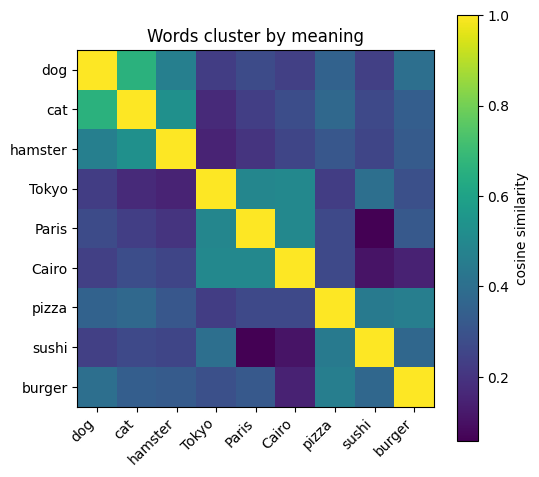

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

words = ["dog", "cat", "hamster",            # animals
         "Tokyo", "Paris", "Cairo",          # cities
         "pizza", "sushi", "burger"]         # foods

embeddings = model.encode(words)
# Pairwise cosine similarity matrix.
sim = np.array([[cosine_similarity(a, b) for b in embeddings] for a in embeddings])

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(sim, cmap="viridis")
ax.set_xticks(range(len(words))); ax.set_xticklabels(words, rotation=45, ha="right")
ax.set_yticks(range(len(words))); ax.set_yticklabels(words)
plt.colorbar(im, label="cosine similarity")
ax.set_title("Words cluster by meaning")
plt.tight_layout(); plt.show()

*The three bright 3×3 blocks on the diagonal are the animal, city, and food clusters — discovered purely from the geometry of the embeddings.*

## Seeing the map in 2D

The embeddings live in 384 dimensions. We can't draw that, so we use **PCA** to project down to the 2 directions that capture the most variation. Clusters that are close in the full space stay close here.

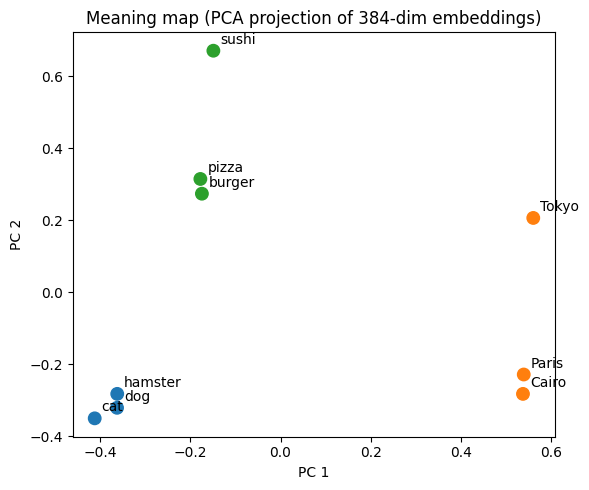

In [4]:
from sklearn.decomposition import PCA

coords = PCA(n_components=2).fit_transform(embeddings)
colors = ["tab:blue"]*3 + ["tab:orange"]*3 + ["tab:green"]*3

plt.figure(figsize=(6, 5))
plt.scatter(coords[:, 0], coords[:, 1], c=colors, s=80)
for (x, y), w in zip(coords, words):
    plt.annotate(w, (x, y), xytext=(5, 5), textcoords="offset points")
plt.title("Meaning map (PCA projection of 384-dim embeddings)")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.tight_layout(); plt.show()

*Three tidy clusters. The exact axes are meaningless — what matters is that semantically similar words land near each other.*

## The payoff: semantic search

Keyword search fails when the user's words don't match the document's words. Embedding search matches on **meaning**. We embed a set of documents once, then embed the query and return whichever documents point in the most similar direction. This is the retrieval half of RAG (notebook 14), in a dozen lines.

In [5]:
documents = [
    "The HeliosArm V2 supports a payload of 5 kg.",
    "To reset the controller, hold the power button for 10 seconds.",
    "Our return policy allows refunds within 30 days of purchase.",
    "The robot's battery lasts approximately 8 hours per charge.",
    "Joint 4 may overheat under continuous high-torque operation.",
]
doc_vecs = model.encode(documents)

def search(query, k=2):
    q = model.encode(query)
    scores = [cosine_similarity(q, d) for d in doc_vecs]
    ranked = sorted(zip(scores, documents), reverse=True)
    return ranked[:k]

# Note: the query shares almost NO keywords with the right answer.
for score, doc in search("how long does it run before needing power?"):
    print(f"{score:.3f}  {doc}")

0.407  The robot's battery lasts approximately 8 hours per charge.
0.155  To reset the controller, hold the power button for 10 seconds.


*The top hit is the battery-life sentence — even though the query said 'run' and 'power', not 'battery' or 'charge'. That's semantic, not keyword, matching.*

## Exercises

In [6]:
# Exercise 1 (Warm-up): Add a category
# Task: Add three "sport" words (e.g. "tennis", "soccer", "chess") to the `words` list,
#       re-embed, and regenerate the heatmap and PCA plot. Does a fourth cluster appear?
# Hint: Just extend the list and update the `colors` list to match the new length.

# YOUR CODE HERE

In [7]:
# Exercise 2 (Apply): Word analogies
# Task: Test the famous "king - man + woman ~= queen" analogy. Embed all four words,
#       compute v = king - man + woman, and find which of [queen, prince, apple] is closest to v.
# Hint: Use cosine_similarity(v, candidate). Sentence embedders are weaker at this than
#       word2vec — report honestly whether it worked.

# YOUR CODE HERE

In [8]:
# Exercise 3 (Extend): Mini-RAG retrieval
# Task: Add 5 more documents to the `documents` list and write a query whose best answer
#       uses NONE of the query's keywords. Confirm semantic search still finds it.
# Hint: This is exactly the 'retrieve' step you'll formalize in notebook 14 (RAG Fundamentals).

# YOUR CODE HERE

<details>
<summary>Show solutions</summary>

```python
# Exercise 2
v = model.encode("king") - model.encode("man") + model.encode("woman")
for cand in ["queen", "prince", "apple"]:
    print(cand, round(cosine_similarity(v, model.encode(cand)), 3))
# Sentence-MiniLM usually ranks 'queen' highest but not dramatically — the clean
# arithmetic of the classic word2vec demo is weaker here. That's an honest finding.

# Exercise 3
documents += [
    "Firmware version 3.2 fixed the joint calibration bug.",
    "The gripper can hold objects up to 2 kg.",
    "Customer support is available Monday to Friday.",
    "The mobile base navigates using LiDAR sensors.",
    "Software updates are delivered over the air.",
]
doc_vecs = model.encode(documents)
print(search("when can I talk to a human for help?"))  # -> the support-hours doc
```
</details>

## Key Takeaways
- An **embedding** is a vector that places meaning in space; nearby vectors mean similar things.
- **Cosine similarity** compares *direction* (angle), so text length doesn't distort the comparison.
- Embedding models reveal semantic structure (clusters) they were never explicitly taught.
- **Semantic search** matches on meaning, not keywords — it's the retrieval engine behind RAG.

## What's Next
Notebook **04 — Attention Mechanism** is the heart of the transformer: how a model decides *which other tokens to look at* when interpreting each word. It builds directly on the dot-product similarity you just used.